# 01_DiatomInventories_GTstudentproject_B 

This file contains the taxon inventories in a long format. These are relative abundances: to compute the Biological Diatom Index (IBD) of a given OP, operators usually identify up to 400 diatom valves. This file contains the following columns:

-   *TaxonName*: full name of diatom taxa identified in the inventories.

-   *TaxonCode*: seven character code correponding to the taxon name. See *07_TaxaCode_GTstudentproject.csv* for a table matching taxa names and codes.

-   *SamplingOperations_code*: code of the diatom sampling operation; it is a combination of the sampling site code and the sampling date.

-   *CodeSite_SamplingOperations*: code of the site (i.e., river reach) where the sampling operation took place.

-   *Date_SamplingOperation*: date of the sampling operation (as *Year-month-day*).

-   *Abundance_nbcell*: number of taxon cells counted for this OP.

-   *TotalAbundance_SamplingOperation*: total number of taxon cells counted for this OP. Because of the sampling protocol, this number should typically be close to 400.

-   *Abundance_pm*: permil taxa abundance (1000 × *Abundance_nbcell/TotalAbundance_SamplingOperation*). gracias por llenarme memoria con una division, entre muchas otras cosas

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [2]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


eee? lol? no llevaron bases de datos con zechi o por que ordenaron tan bien?

In [9]:
dfs[list(dfs.keys())[0]] # First parquet

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8,420,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1,404,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1,400,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2,400,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1,400,2.500000
...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1,412,2.427184
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1,400,2.500000
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1,403,2.481390
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7,400,17.500000


In [10]:
dfs[list(dfs.keys())[0]].nunique()  # Unique values in each column of the first dataframe

TaxonName                            2292
TaxonCode                            2292
SamplingOperations_code             49231
CodeSite_SamplingOperations          8404
Date_SamplingOperation               2237
Abundance_nbcell                      408
TotalAbundance_SamplingOperation      188
Abundance_pm                        16667
dtype: int64

In [29]:
dfs[list(dfs.keys())[0]] # First parquet

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm,taxonNumberLol
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8,420,19.047619,0
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1,404,2.475248,0
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1,400,2.500000,1
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2,400,5.000000,1
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1,400,2.500000,1
...,...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1,412,2.427184,2291
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1,400,2.500000,2291
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1,403,2.481390,2291
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7,400,17.500000,2291


In [77]:
pd.set_option('display.max_rows', None)

In [78]:
# view the values of the first column
dfs[list(dfs.keys())[0]].iloc[:, 0].value_counts()

TaxonName
Achnanthes minutissima                   43691
Amphora pediculus                        39209
Cocconeis euglypta                       38570
Sellaphora nigri                         38039
Navicula cryptotenella                   37723
Nitzschia dissipata                      34461
Vibrio tripunctatus                      30899
Rhoicosphenia abbreviata                 30560
Navicula permitis                        29789
Achnanthes lanceolata                    27239
Navicula gregaria                        26392
Gomphonema parvulum                      25592
Nitzschia palea                          25078
Melosira varians                         22779
Reimeria sinuata                         22418
Gomphonema minutum                       21142
Nitzschia sociabilis                     20578
Navicula antonii                         20337
Cocconeis placentula                     20156
Navicula saprophila                      18903
Planothidium lanceolatum                 18900
Nav

In [79]:
# view the values of the first column in alphabetical order
dfs[list(dfs.keys())[0]].iloc[:, 0].value_counts().sort_index()

TaxonName
Achnanthes aapajaervensis                    2
Achnanthes affinis                         176
Achnanthes amphicephala                     41
Achnanthes atomus                            6
Achnanthes biasolettiana                    26
Achnanthes bioretii                         28
Achnanthes brevipes                         43
Achnanthes carissima                         1
Achnanthes catenata                       2960
Achnanthes chlidanos                         6
Achnanthes clevei                            4
Achnanthes coarctata                        72
Achnanthes conspicua                      5336
Achnanthes convergens                        7
Achnanthes crassa                          462
Achnanthes cyclophora                        1
Achnanthes daonensis                       937
Achnanthes daui                           1611
Achnanthes deflexa                          13
Achnanthes didyma                            3
Achnanthes distincta                         1
Ach

Género + epíteto específico

In [82]:
len(dfs[list(dfs.keys())[0]].iloc[:, 0].value_counts())

2292

Hay 2292 Diatomic Taxa 

In [74]:
dfs[list(dfs.keys())[0]].iloc[:, 0].str.split(' ', n=1).str[0].value_counts().sort_index()

TaxonName
Achnanthes              148679
Achnanthidium            38998
Actinella                    2
Actinocyclus                90
Actinoptychus                3
Adlafia                   3115
Afrocymbella                 1
Amphicocconeis               1
Amphipleura                647
Amphiprora                  11
Amphora                  71355
Amphorotia                   2
Anaulus                      1
Aneumastus                   9
Anomoeoneis                 67
Anorthoneis                  1
Asterionella               988
Aulacoseira               7832
Azpeitia                     1
Bacillaria                1259
Berkeleya                  117
Biblarium                  360
Biremis                      1
Brachysira                 851
Brevilinea                  64
Caloneis                 17313
Campylodiscus               33
Campylosira                  5
Capartogramma               99
Catenula                     1
Cavinula                     1
Centronella                  

In [83]:
len(dfs[list(dfs.keys())[0]].iloc[:, 0].str.split(' ', n=1).str[0].value_counts())

204

In [75]:
dfs[list(dfs.keys())[0]].iloc[:, 0].str.split(' ', n=1).str[1].value_counts().sort_index()

TaxonName
(as                      433
aapajaervensis             2
abbreviata             30586
abbreviatum               45
abscondita                 4
absoluta                  91
abunda                     1
abundans                 179
accedens                   1
acceptata               5861
accommoda               1267
accommodata                3
accomodiformis             4
acicularioides            10
acicularis              2611
acidobionta                1
acidoclinata            2513
acidoclinatiforme         76
acidoclinatum            493
acidophila                 5
acrospheria               13
acsiae                    15
actinastroides             1
acula                    634
aculeata                   1
acuminata                 69
acuminatum              2096
acus                     649
acuta                      8
acutirostrata              2
acutirostris               1
acutiuscula                9
acutobrebissonii          42
adamata                  538
adha

In [80]:
pd.reset_option('display.max_rows')        # back to default

<Figure size 1000x600 with 0 Axes>

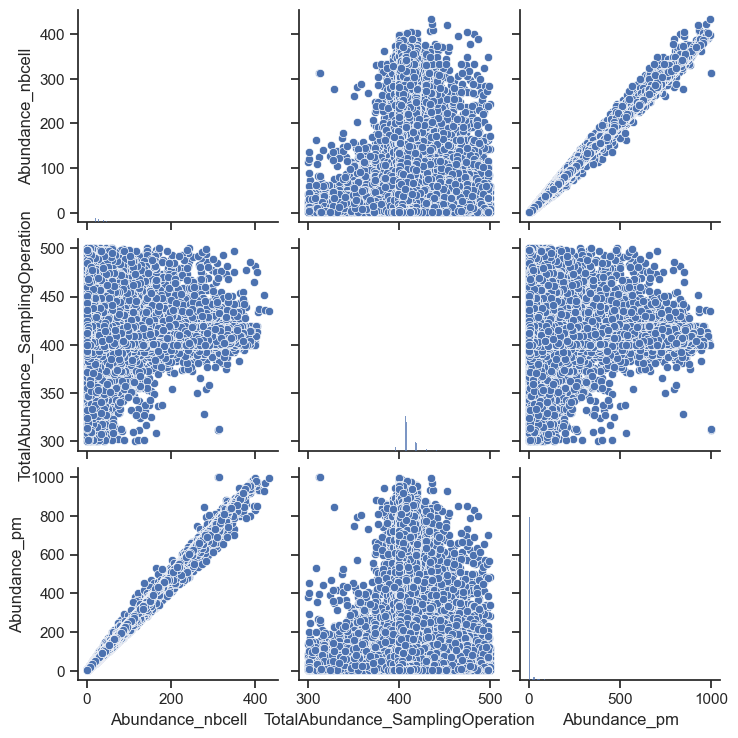

In [ ]:
plt.figure(figsize=(10, 6))
sns.pairplot(dfs[list(dfs.keys())[0]][['Abundance_nbcell', 'TotalAbundance_SamplingOperation', 'Abundance_pm']])
plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.pairplot(dfs[list(dfs.keys())[0]][['Abundance_nbcell', 'TotalAbundance_SamplingOperation', 'Abundance_pm']], diag_kind='kde', kind='kde')
# plt.show()

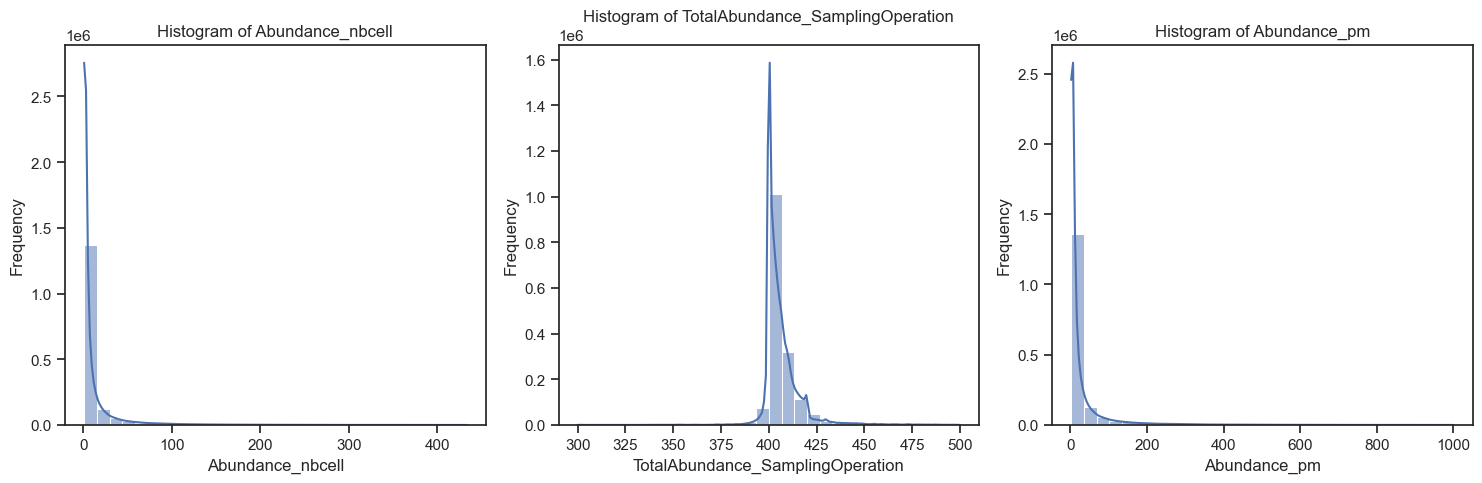

In [84]:
# Create histograms for each variable in the dataframe
df = dfs[list(dfs.keys())[0]][['Abundance_nbcell', 'TotalAbundance_SamplingOperation', 'Abundance_pm']]

# Plot histograms
plt.figure(figsize=(15, 5))
for i, column in enumerate(df.columns, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()